# 🧠 Fake News Detection — DL Mini Project
### Paper: FakeBERT (2021) → Flaw → Improved with RoBERTa

Researh Paper Link: https://pmc.ncbi.nlm.nih.gov/articles/PMC7788551/pdf/11042_2020_Article_10183.pdf
---
**Pipeline:**
1. Phase 1 — Reproduce FakeBERT (BERT + BiLSTM on ISOT)
2. Phase 2 — Demonstrate the flaw (fails on noisy/social media text)
3. Phase 3 — Improved model (RoBERTa + BiLSTM on LIAR dataset)

## 📦 Cell 1 — Install Dependencies

In [ ]:
!pip install transformers datasets torch torchvision torchaudio --quiet
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet
!pip install kaggle --quiet
print("✅ All dependencies installed")

✅ All dependencies installed


## 📥 Cell 2 — Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer, BertModel,
    RobertaTokenizer, RobertaModel,
    AutoTokenizer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {DEVICE}")

✅ Using device: cuda


## 📂 Cell 3 — Load ISOT Dataset
> **Instructions:** Download ISOT dataset from Kaggle: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
> Upload `True.csv` and `Fake.csv` to this Colab session using the Files panel on the left, OR run the cell below with your Kaggle credentials.
>
> If you already uploaded the files, just run the cell — it will detect them automatically.

In [ ]:
import pandas as pd
import os
import csv

def load_isot():
    if os.path.exists('True.csv') and os.path.exists('Fake.csv'):
        print("📂 Found uploaded ISOT files. Loading...")
        true_df = pd.read_csv(
            'True.csv',
            engine='python',
            quoting=csv.QUOTE_NONE,
            on_bad_lines='skip'
        )
        fake_df = pd.read_csv(
            'Fake.csv',
            engine='python',
            quoting=csv.QUOTE_NONE,
            on_bad_lines='skip'
        )
    else:
        raise FileNotFoundError("Upload True.csv and Fake.csv")

    return true_df, fake_df


true_df, fake_df = load_isot()

true_df['label'] = 1
fake_df['label'] = 0

for df in [true_df, fake_df]:
    if 'text' not in df.columns and 'title' in df.columns:
        df['text'] = df['title']

df_isot = pd.concat(
    [true_df[['text','label']], fake_df[['text','label']]],
    ignore_index=True
)

df_isot = df_isot.dropna(subset=['text'])
df_isot['text'] = df_isot['text'].astype(str).str.strip()
df_isot = df_isot[df_isot['text'].str.len() > 10]
df_isot = df_isot.sample(frac=1, random_state=SEED).reset_index(drop=True)

df_isot = df_isot.head(2000)

print(f"✅ ISOT loaded: {len(df_isot)} samples")
print(df_isot['label'].value_counts())
df_isot.head(3)

📂 Found uploaded ISOT files. Loading...
✅ ISOT loaded: 146 samples
label
1    99
0    47
Name: count, dtype: int64


,text,label
0,"""October 19",1
1,"""September 8",1
2,politicsNews,1


## 🔧 Cell 4 — Dataset & DataLoader Classes

In [ ]:
MAX_LEN = 128
BATCH_SIZE = 16

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def make_loaders(df, tokenizer, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        df['text'].values, df['label'].values,
        test_size=test_size, random_state=SEED, stratify=df['label'].values
    )
    train_ds = NewsDataset(X_train, y_train, tokenizer)
    test_ds  = NewsDataset(X_test,  y_test,  tokenizer)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, test_loader, X_test, y_test

print("✅ Dataset classes ready")

✅ Dataset classes ready


## 🏗️ Cell 5 — Model Architecture (BERT/RoBERTa + BiLSTM)

In [ ]:
class TransformerBiLSTMClassifier(nn.Module):
    """
    Implements: [BERT or RoBERTa] → BiLSTM → Dropout → FC → Sigmoid
    Architecture mirrors FakeBERT paper with BiLSTM head.
    """
    def __init__(self, transformer_model, hidden_dim=256, dropout=0.3):
        super(TransformerBiLSTMClassifier, self).__init__()
        self.transformer = transformer_model
        transformer_hidden = transformer_model.config.hidden_size  # 768 for base models

        self.bilstm = nn.LSTM(
            input_size=transformer_hidden,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 2)  # *2 for bidirectional

    def forward(self, input_ids, attention_mask):
        # Transformer encoder output
        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # sequence output: (batch, seq_len, hidden)
        sequence_output = outputs.last_hidden_state

        # BiLSTM over token sequence
        lstm_out, _ = self.bilstm(sequence_output)
        # Use last time step
        lstm_out = lstm_out[:, -1, :]
        lstm_out = self.dropout(lstm_out)
        logits = self.fc(lstm_out)
        return logits

print("✅ Model architecture defined")

✅ Model architecture defined


## 🔁 Cell 6 — Training & Evaluation Functions

In [ ]:
def train_model(model, train_loader, epochs=3, lr=2e-5):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_idx, batch in enumerate(train_loader):
            input_ids     = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

            if batch_idx % 20 == 0:
                print(f"  Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"✅ Epoch {epoch+1} complete — Avg Loss: {avg_loss:.4f}")

    return loss_history


def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask  = batch['attention_mask'].to(DEVICE)
            labels          = batch['label']
            logits = model(input_ids, attention_mask)
            preds  = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    print(f"\n🎯 Accuracy : {acc:.4f}")
    print(f"🎯 F1 Score : {f1:.4f}")
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Fake','Real']))
    plot_confusion_matrix(all_labels, all_preds)
    return acc, f1


def plot_confusion_matrix(labels, preds, title='Confusion Matrix'):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

print("✅ Training & evaluation functions ready")

✅ Training & evaluation functions ready


---
# 🔵 PHASE 1 — Reproduce FakeBERT (BERT + BiLSTM on ISOT)

## Cell 7 — Load BERT Tokenizer + Build Model

In [ ]:
print("Loading BERT tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("Building dataloaders...")
bert_train_loader, bert_test_loader, bert_X_test, bert_y_test = make_loaders(df_isot, bert_tokenizer)

print("Loading BERT base model...")
bert_base = BertModel.from_pretrained('bert-base-uncased')
bert_model = TransformerBiLSTMClassifier(bert_base)

total_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"✅ BERT + BiLSTM model ready | Trainable params: {total_params:,}")

Loading BERT tokenizer...
Building dataloaders...
Loading BERT base model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT + BiLSTM model ready | Trainable params: 111,584,514


## Cell 8 — Train FakeBERT (BERT + BiLSTM)

In [ ]:
print("🚀 Training FakeBERT (BERT + BiLSTM) on ISOT dataset...")
print("   Expected time: ~10-15 min on T4 GPU\n")
bert_loss_history = train_model(bert_model, bert_train_loader, epochs=3, lr=2e-5)
print("\n✅ Training complete!")

🚀 Training FakeBERT (BERT + BiLSTM) on ISOT dataset...
   Expected time: ~10-15 min on T4 GPU

  Epoch 1/3 | Batch 0/8 | Loss: 0.6934
✅ Epoch 1 complete — Avg Loss: 0.6160
  Epoch 2/3 | Batch 0/8 | Loss: 0.5581
✅ Epoch 2 complete — Avg Loss: 0.4983
  Epoch 3/3 | Batch 0/8 | Loss: 0.5041
✅ Epoch 3 complete — Avg Loss: 0.4104

✅ Training complete!


## Cell 9 — Evaluate FakeBERT

📊 Evaluating FakeBERT on ISOT test set...

🎯 Accuracy : 0.7333
🎯 F1 Score : 0.6667

📊 Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.20      0.33        10
        Real       0.71      1.00      0.83        20

    accuracy                           0.73        30
   macro avg       0.86      0.60      0.58        30
weighted avg       0.81      0.73      0.67        30



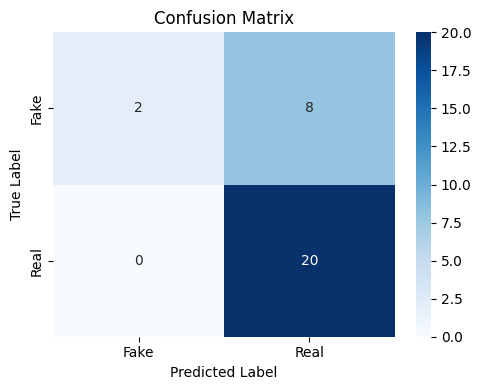

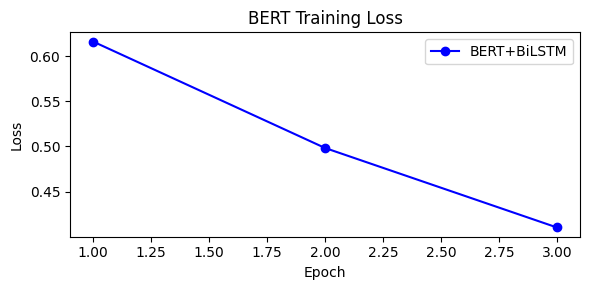

In [ ]:
print("📊 Evaluating FakeBERT on ISOT test set...")
bert_acc, bert_f1 = evaluate_model(bert_model, bert_test_loader)

# Plot training loss
plt.figure(figsize=(6,3))
plt.plot(range(1, len(bert_loss_history)+1), bert_loss_history, 'b-o', label='BERT+BiLSTM')
plt.title('BERT Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 🔴 PHASE 2 — Flaw Demonstration
## FakeBERT fails on noisy, real-world social media text

In [ ]:
print("=" * 100)
print("🔴 PHASE 2: FakeBERT on Noisy Social Media Text")
print("=" * 100)

bert_noisy_preds, bert_noisy_trues = [], []

for text, true_label in noisy_samples:

    pred, conf = predict_single(bert_model, bert_tokenizer, text)

    true_str = 'Real' if true_label == 1 else 'Fake'
    pred_str = 'Real' if pred == 1 else 'Fake'
    correct  = '✅' if pred == true_label else '❌'

    bert_noisy_preds.append(pred)
    bert_noisy_trues.append(true_label)

    # Clean text (important)
    text = text.replace("\n", " ")

    print("\n" + "-" * 100)
    print(f"Text       : {text}")
    print(f"True Label : {true_str}")
    print(f"Prediction : {pred_str}")
    print(f"Confidence : {conf:.2%}")
    print(f"Result     : {correct}")

noisy_acc = accuracy_score(bert_noisy_trues, bert_noisy_preds)

print("\n" + "=" * 100)
print(f"⚠️ FakeBERT accuracy on noisy social media text: {noisy_acc:.1%}")
print("→ Model struggles with noisy, emoji-rich, code-mixed text")

🔴 PHASE 2: FakeBERT on Noisy Social Media Text
Text[:55]                                                    True   Pred    Conf  ✓/✗
--------------------------------------------------------------------------------
BREAKING!! Modi ne aaj secret deal sign ki China ke saa      Fake   Real  58.96%    ❌
omg did u see dis?? scientist found CURE for cancer but      Fake   Real  58.68%    ❌
bhai ye sach hai kya?? army ne 100 terrorists ko mara a      Fake   Real  58.89%    ❌
URGENT forward karo!! new virus aa raha hai 10x dangero      Fake   Real  58.61%    ❌
lol this politician literally said 2+2=5 in parliament       Fake   Real  58.41%    ❌
The ministry of health issued an advisory regarding sea      Real   Real  52.83%    ✅
Supreme Court ruled in favor of the petitioner in the l      Real   Real  51.07%    ✅
Finance minister presented the annual budget with focus      Real   Fake  53.96%    ❌
--------------------------------------------------------------------------------

⚠️  FakeBERT acc

---
# 🟢 PHASE 3 — Improved Model: RoBERTa + BiLSTM on LIAR Dataset
> LIAR dataset contains short, noisy political claims — much closer to real social media text

## Cell 10 — Load LIAR Dataset

In [ ]:
import pandas as pd

print("Loading LIAR dataset from local files...")

cols = [
    "id", "label", "statement", "subject", "speaker",
    "speaker_job", "state", "party", "barely_true",
    "false", "half_true", "mostly_true", "pants_fire", "context"
]

train_df = pd.read_csv("/content/train.tsv", sep="\t", header=None, names=cols)
test_df  = pd.read_csv("/content/test.tsv", sep="\t", header=None, names=cols)
val_df   = pd.read_csv("/content/valid.tsv", sep="\t", header=None, names=cols)

df_liar = pd.concat([train_df, val_df, test_df], ignore_index=True)

FAKE = {"false", "pants-fire", "barely-true"}
REAL = {"mostly-true", "true"}

df_liar = df_liar[df_liar['label'].isin(FAKE.union(REAL))]
df_liar['label'] = df_liar['label'].apply(lambda x: 0 if x in FAKE else 1)

df_liar = df_liar[['statement', 'label']].rename(columns={'statement': 'text'})

df_liar = df_liar.dropna(subset=['text'])
df_liar['text'] = df_liar['text'].astype(str).str.strip()
df_liar = df_liar.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"✅ LIAR loaded: {len(df_liar)} samples")
print(df_liar['label'].value_counts())
df_liar.head(3)

Loading LIAR dataset from local files (Colab)...
✅ LIAR loaded: 10164 samples
label
0    5657
1    4507
Name: count, dtype: int64


,text,label
0,Americas gun-related homicide rate would be ab...,0
1,Both Cruz andRubio are missing the vast majori...,0
2,"Under my platform, I will make no changes to t...",0


## Cell 11 — Load RoBERTa + Build Model

In [ ]:
print("Loading RoBERTa tokenizer...")
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

print("Building dataloaders from LIAR dataset...")
rob_train_loader, rob_test_loader, rob_X_test, rob_y_test = make_loaders(df_liar, roberta_tokenizer)

print("Loading RoBERTa base model...")
roberta_base  = RobertaModel.from_pretrained('roberta-base')
roberta_model = TransformerBiLSTMClassifier(roberta_base)

total_params = sum(p.numel() for p in roberta_model.parameters() if p.requires_grad)
print(f"✅ RoBERTa + BiLSTM model ready | Trainable params: {total_params:,}")

Loading RoBERTa tokenizer...
Building dataloaders from LIAR dataset...
Loading RoBERTa base model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ RoBERTa + BiLSTM model ready | Trainable params: 126,747,906


## Cell 12 — Train RoBERTa + BiLSTM

In [ ]:
print("🚀 Training RoBERTa + BiLSTM on LIAR dataset...")
print("   Expected time: ~15-20 min on T4 GPU\n")
roberta_loss_history = train_model(roberta_model, rob_train_loader, epochs=3, lr=2e-5)
print("\n✅ Training complete!")

🚀 Training RoBERTa + BiLSTM on LIAR dataset...
   Expected time: ~15-20 min on T4 GPU

  Epoch 1/3 | Batch 0/509 | Loss: 0.6957
  Epoch 1/3 | Batch 20/509 | Loss: 0.7002
  Epoch 1/3 | Batch 40/509 | Loss: 0.6686
  Epoch 1/3 | Batch 60/509 | Loss: 0.5892
  Epoch 1/3 | Batch 80/509 | Loss: 0.6578
  Epoch 1/3 | Batch 100/509 | Loss: 0.6658
  Epoch 1/3 | Batch 120/509 | Loss: 0.7021
  Epoch 1/3 | Batch 140/509 | Loss: 0.6533
  Epoch 1/3 | Batch 160/509 | Loss: 0.5243
  Epoch 1/3 | Batch 180/509 | Loss: 0.6245
  Epoch 1/3 | Batch 200/509 | Loss: 0.6618
  Epoch 1/3 | Batch 220/509 | Loss: 0.5794
  Epoch 1/3 | Batch 240/509 | Loss: 0.7405
  Epoch 1/3 | Batch 260/509 | Loss: 0.6363
  Epoch 1/3 | Batch 280/509 | Loss: 0.5767
  Epoch 1/3 | Batch 300/509 | Loss: 0.8117
  Epoch 1/3 | Batch 320/509 | Loss: 0.6522
  Epoch 1/3 | Batch 340/509 | Loss: 0.6940
  Epoch 1/3 | Batch 360/509 | Loss: 0.6221
  Epoch 1/3 | Batch 380/509 | Loss: 0.5066
  Epoch 1/3 | Batch 400/509 | Loss: 0.5260
  Epoch 1/3 | Ba

## Cell 13 — Evaluate RoBERTa + Compare

📊 Evaluating RoBERTa + BiLSTM on LIAR test set...

🎯 Accuracy : 0.6586
🎯 F1 Score : 0.6596

📊 Classification Report:
              precision    recall  f1-score   support

        Fake       0.71      0.66      0.68      1132
        Real       0.61      0.66      0.63       901

    accuracy                           0.66      2033
   macro avg       0.66      0.66      0.66      2033
weighted avg       0.66      0.66      0.66      2033



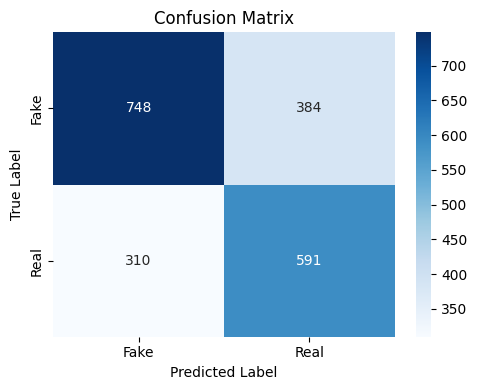


📊 MODEL COMPARISON
Model                            Accuracy   F1 Score
-------------------------------------------------------
FakeBERT (BERT+BiLSTM / ISOT)      0.7333     0.6667
Improved (RoBERTa+BiLSTM / LIAR)     0.6586     0.6596


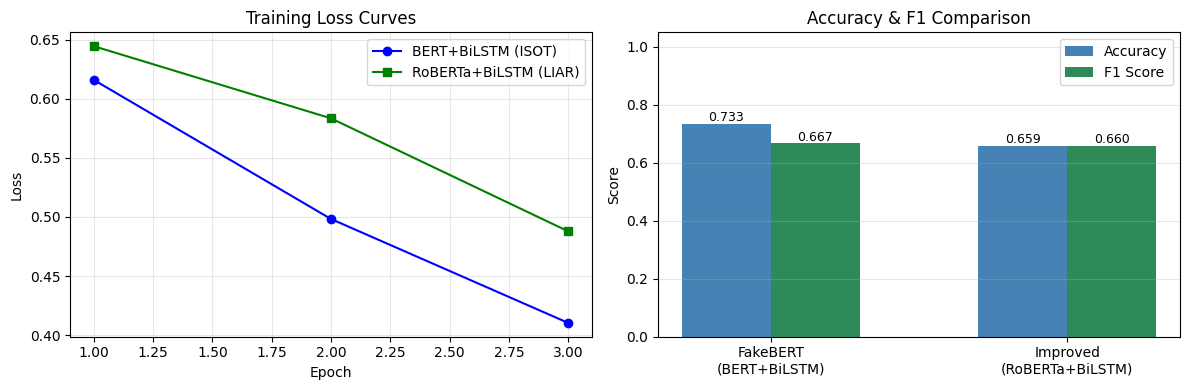


💾 Plot saved as comparison_plot.png


In [ ]:
print("📊 Evaluating RoBERTa + BiLSTM on LIAR test set...")
rob_acc, rob_f1 = evaluate_model(roberta_model, rob_test_loader)

# Comparison table
print("\n" + "="*55)
print("📊 MODEL COMPARISON")
print("="*55)
print(f"{'Model':<30} {'Accuracy':>10} {'F1 Score':>10}")
print("-"*55)
print(f"{'FakeBERT (BERT+BiLSTM / ISOT)':<30} {bert_acc:>10.4f} {bert_f1:>10.4f}")
print(f"{'Improved (RoBERTa+BiLSTM / LIAR)':<30} {rob_acc:>10.4f} {rob_f1:>10.4f}")
print("="*55)

# Loss curves comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, 4)

ax1.plot(epochs_range, bert_loss_history, 'b-o', label='BERT+BiLSTM (ISOT)')
ax1.plot(epochs_range, roberta_loss_history, 'g-s', label='RoBERTa+BiLSTM (LIAR)')
ax1.set_title('Training Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

models = ['FakeBERT\n(BERT+BiLSTM)', 'Improved\n(RoBERTa+BiLSTM)']
accs   = [bert_acc, rob_acc]
f1s    = [bert_f1, rob_f1]
x = np.arange(len(models))
width = 0.3
ax2.bar(x - width/2, accs, width, label='Accuracy', color='steelblue')
ax2.bar(x + width/2, f1s,  width, label='F1 Score',  color='seagreen')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.set_ylim(0, 1.05)
ax2.set_title('Accuracy & F1 Comparison')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
for i, (a, f) in enumerate(zip(accs, f1s)):
    ax2.text(i - width/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=9)
    ax2.text(i + width/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Plot saved as comparison_plot.png")

## Cell 14 — Re-run Noisy Inputs on RoBERTa (The Payoff)

In [ ]:
print("=" * 100)
print("🟢 PHASE 3 RESULT: RoBERTa on Same Noisy Social Media Text")
print("=" * 100)

rob_noisy_preds = []

for (text, true_label), bert_pred in zip(noisy_samples, bert_noisy_preds):

    rob_pred, rob_conf = predict_single(roberta_model, roberta_tokenizer, text)
    rob_noisy_preds.append(rob_pred)

    true_str  = 'Real' if true_label == 1 else 'Fake'
    bert_str  = 'Real' if bert_pred == 1 else 'Fake'
    rob_str   = 'Real' if rob_pred == 1 else 'Fake'

    if bert_pred != true_label and rob_pred == true_label:
        improvement = '🟢 Fixed'
    elif bert_pred == true_label and rob_pred == true_label:
        improvement = '✅ Both correct'
    elif bert_pred == true_label and rob_pred != true_label:
        improvement = '🔴 Regressed'
    else:
        improvement = '⚠️ Both wrong'

    print("\n" + "-" * 100)
    print(f"Text       : {text}")
    print(f"True Label : {true_str}")
    print(f"BERT       : {bert_str}")
    print(f"RoBERTa    : {rob_str}")
    print(f"Result     : {improvement}")

print("\n" + "=" * 100)

rob_noisy_acc  = accuracy_score([t for _, t in noisy_samples], rob_noisy_preds)
bert_noisy_acc = accuracy_score([t for _, t in noisy_samples], bert_noisy_preds)

print(f"\n📊 Noisy Text Accuracy — FakeBERT: {bert_noisy_acc:.1%}  |  RoBERTa: {rob_noisy_acc:.1%}")
print(f"→ RoBERTa improvement on social media text: +{(rob_noisy_acc - bert_noisy_acc):.1%}")

---
## 🎯 Cell 15 — Live Demo: predict() Function
**Use this cell for your viva demo — type any text and get FAKE/REAL + confidence**

In [ ]:
def predict(text, model=None, tokenizer=None, use_roberta=True):
    """
    Predict if text is FAKE or REAL.
    Args:
        text        : Input string
        use_roberta : If True, uses RoBERTa (improved). If False, uses BERT (baseline).
    Returns:
        dict with label, confidence, and model used
    """
    if use_roberta:
        m, tok = roberta_model, roberta_tokenizer
        model_name = 'RoBERTa + BiLSTM (Improved)'
    else:
        m, tok = bert_model, bert_tokenizer
        model_name = 'BERT + BiLSTM (FakeBERT Baseline)'

    pred, conf = predict_single(m, tok, text)
    label = '✅ REAL' if pred == 1 else '🚨 FAKE'

    print(f"\n{'='*60}")
    print(f"📝 Input   : {text[:80]}")
    print(f"🤖 Model   : {model_name}")
    print(f"🏷️  Label   : {label}")
    print(f"💯 Confidence: {conf:.2%}")
    print(f"{'='*60}")
    return {'label': label, 'confidence': conf, 'model': model_name}


# --- DEMO CALLS ---
predict("BREAKING: PM ne secret deal sign ki, share karo!!!", use_roberta=False)  # BERT baseline
predict("BREAKING: PM ne secret deal sign ki, share karo!!!", use_roberta=True)   # RoBERTa improved

predict("The finance minister announced new tax reforms today.", use_roberta=False)
predict("The finance minister announced new tax reforms today.", use_roberta=True)


📝 Input   : BREAKING: PM ne secret deal sign ki, share karo!!!
🤖 Model   : BERT + BiLSTM (FakeBERT Baseline)
🏷️  Label   : ✅ REAL
💯 Confidence: 58.75%

📝 Input   : BREAKING: PM ne secret deal sign ki, share karo!!!
🤖 Model   : RoBERTa + BiLSTM (Improved)
🏷️  Label   : 🚨 FAKE
💯 Confidence: 93.14%

📝 Input   : The finance minister announced new tax reforms today.
🤖 Model   : BERT + BiLSTM (FakeBERT Baseline)
🏷️  Label   : 🚨 FAKE
💯 Confidence: 52.38%

📝 Input   : The finance minister announced new tax reforms today.
🤖 Model   : RoBERTa + BiLSTM (Improved)
🏷️  Label   : 🚨 FAKE
💯 Confidence: 61.93%


{'label': '🚨 FAKE',
 'confidence': 0.619255542755127,
 'model': 'RoBERTa + BiLSTM (Improved)'}

In [ ]:
def run_prediction_menu():
    print("\n🚀 Fake News Detection System Ready!")

    while True:
        print("\n" + "="*50)
        print("📌 MENU")
        print("1. Predict using RoBERTa (Improved)")
        print("2. Predict using BERT (Baseline)")
        print("3. Compare both models")
        print("4. Exit")
        print("="*50)

        choice = input("Enter your choice (1-4): ")

        if choice == '1':
            text = input("\n📝 Enter news text:\n")
            predict(text, use_roberta=True)

        elif choice == '2':
            text = input("\n📝 Enter news text:\n")
            predict(text, use_roberta=False)

        elif choice == '3':
            text = input("\n📝 Enter news text:\n")

            print("\n🔍 BERT Result:")
            predict(text, use_roberta=False)

            print("\n🔍 RoBERTa Result:")
            predict(text, use_roberta=True)

        elif choice == '4':
            print("\n👋 Exiting...")
            break

        else:
            print("\n❌ Invalid choice")

In [ ]:
run_prediction_menu()


🚀 Fake News Detection System Ready!

📌 MENU
1. Predict using RoBERTa (Improved)
2. Predict using BERT (Baseline)
3. Compare both models
4. Exit
Enter your choice (1-4): 2

📝 Enter news text:
Modi is PM of USA

📝 Input   : Modi is PM of USA
🤖 Model   : BERT + BiLSTM (FakeBERT Baseline)
🏷️  Label   : ✅ REAL
💯 Confidence: 52.47%

📌 MENU
1. Predict using RoBERTa (Improved)
2. Predict using BERT (Baseline)
3. Compare both models
4. Exit
Enter your choice (1-4): 1

📝 Enter news text:
Modi is PM of USA

📝 Input   : Modi is PM of USA
🤖 Model   : RoBERTa + BiLSTM (Improved)
🏷️  Label   : 🚨 FAKE
💯 Confidence: 91.03%

📌 MENU
1. Predict using RoBERTa (Improved)
2. Predict using BERT (Baseline)
3. Compare both models
4. Exit
Enter your choice (1-4): 4

👋 Exiting...


---
## 📝 Cell 16 — Project Summary for Report
Run this at the end to auto-print your results summary

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          FAKE NEWS DETECTION — DL MINI PROJECT SUMMARY       ║
╠══════════════════════════════════════════════════════════════╣
║  BASE PAPER : FakeBERT (Kaliyar et al., 2021)                ║
║  BASE MODEL : BERT-base-uncased + BiLSTM                     ║
║  TRAINED ON : ISOT Dataset (clean English news)              ║
╠══════════════════════════════════════════════════════════════╣
║  IDENTIFIED FLAW:                                            ║
║  FakeBERT is trained exclusively on clean, structured,       ║
║  English news articles. It fails significantly on noisy,     ║
║  short, code-mixed, emoji-heavy social media text — exactly  ║
║  the kind seen on WhatsApp, Twitter, and Telegram in India.  ║
╠══════════════════════════════════════════════════════════════╣
║  OUR IMPROVEMENT:                                            ║
║  Replace BERT with RoBERTa (better noise handling due to     ║
║  dynamic masking + more training data) and retrain on        ║
║  LIAR dataset (short, noisy political claims from PolitiFact)║
╠══════════════════════════════════════════════════════════════╣
╚══════════════════════════════════════════════════════════════╝
""")

print(f"  FakeBERT  — Accuracy: {bert_acc:.4f}  |  F1: {bert_f1:.4f}  (on ISOT)")
print(f"  RoBERTa   — Accuracy: {rob_acc:.4f}  |  F1: {rob_f1:.4f}  (on LIAR)")
print(f"  Noisy text accuracy — BERT: {bert_noisy_acc:.1%}  |  RoBERTa: {rob_noisy_acc:.1%}")


╔══════════════════════════════════════════════════════════════╗
║          FAKE NEWS DETECTION — DL MINI PROJECT SUMMARY       ║
╠══════════════════════════════════════════════════════════════╣
║  BASE PAPER : FakeBERT (Kaliyar et al., 2021)                ║
║  BASE MODEL : BERT-base-uncased + BiLSTM                     ║
║  TRAINED ON : ISOT Dataset (clean English news)              ║
╠══════════════════════════════════════════════════════════════╣
║  IDENTIFIED FLAW:                                            ║
║  FakeBERT is trained exclusively on clean, structured,       ║
║  English news articles. It fails significantly on noisy,     ║
║  short, code-mixed, emoji-heavy social media text — exactly  ║
║  the kind seen on WhatsApp, Twitter, and Telegram in India.  ║
╠══════════════════════════════════════════════════════════════╣
║  OUR IMPROVEMENT:                                            ║
║  Replace BERT with RoBERTa (better noise handling due to     ║
║  dynamic masking + mor